In [ ]:
import pandas as pd
import pandas_gbq

# Replace with your actual GCP Project ID
PROJECT_ID = 'chess-engine-metrics-agent'

# Replace with your BigQuery table reference (e.g., 'your_dataset.your_table')
TABLE_ID = 'conformed_layer.game_data'

In [ ]:
query_unique_games = f"""SELECT COUNT(DISTINCT game_id) AS unique_games_count FROM `{PROJECT_ID}.{TABLE_ID}`"""
unique_games_df = pandas_gbq.read_gbq(query_unique_games, project_id=PROJECT_ID)
display(unique_games_df)

Downloading: 100%|██████████|


,unique_games_count
0,5069


Now, let's load the game data to understand its structure. This will help us determine how to build a comparative stack rank that accounts for opponent strength, as you requested.

In [ ]:
query_all_games = f"""SELECT * FROM `{PROJECT_ID}.{TABLE_ID}` LIMIT 1000""" # Limiting to 1000 rows for initial inspection
games_df = pandas_gbq.read_gbq(query_all_games, project_id=PROJECT_ID)
display(games_df.head())
print(games_df.info())

Downloading: 100%|██████████|


,game_id,date,time,engine_version,event,color,outcome,result,v7p3r_elo,opponent,...,termination,move_count,url,ingested_at,game_type,is_v7p3r_elo_reliable,is_opponent_elo_reliable,relative_opponent_strength,expected_score,actual_score
0,ySGmApwq,2025-12-15,08:05:55,v17.7,rated rapid game,white,draw,1/2-1/2,1602,c0br4_bot,...,Normal,71,https://lichess.org/ySGmApwq,2026-04-30 18:01:17.987684+00:00,lichess_rated,True,True,equal,0.621297,0.5
1,9q9KswiN,2025-11-25,15:37:38,v17.2.0,rated rapid game,black,draw,1/2-1/2,1590,Boosted_Maia_1700,...,Normal,104,https://lichess.org/9q9KswiN,2026-04-30 18:01:17.987684+00:00,lichess_rated,True,True,stronger,0.118261,0.5
2,cWuH02Tf,2025-12-07,14:58:43,v17.7,rated blitz game,black,draw,1/2-1/2,1410,TuroBot,...,Normal,90,https://lichess.org/cWuH02Tf,2026-04-30 18:01:17.987684+00:00,lichess_rated,True,True,weaker,0.804725,0.5
3,OBPkcaIR,2025-11-21,08:30:31,v17.2.0,rated blitz game,black,draw,1/2-1/2,1216,c0br4_bot,...,Normal,112,https://lichess.org/OBPkcaIR,2026-04-30 18:01:17.987684+00:00,lichess_rated,True,True,stronger,0.236075,0.5
4,mORLjBTr,2025-10-03,21:50:51,v12.4,rated rapid game,black,draw,1/2-1/2,1523,joshsbot,...,Normal,254,https://lichess.org/mORLjBTr,2026-04-30 18:01:17.987684+00:00,lichess_rated,True,True,equal,0.471249,0.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   game_id                     1000 non-null   object             
 1   date                        1000 non-null   dbdate             
 2   time                        1000 non-null   dbtime             
 3   engine_version              1000 non-null   object             
 4   event                       1000 non-null   object             
 5   color                       1000 non-null   object             
 6   outcome                     1000 non-null   object             
 7   result                      1000 non-null   object             
 8   v7p3r_elo                   1000 non-null   Int64              
 9   opponent                    1000 non-null   object             
 10  opponent_elo                1000 non-null   Int64            

In [ ]:
# Calculate a performance metric for each game
games_df['performance_metric'] = games_df['actual_score'] - games_df['expected_score']

# Group by engine_version and calculate the mean performance metric
engine_performance = games_df.groupby('engine_version')['performance_metric'].mean().reset_index()

# Sort to get the ranking (higher performance_metric is better)
engine_performance = engine_performance.sort_values(by='performance_metric', ascending=False)

print("Comparative Stack Rank of Engine Versions:")
display(engine_performance)

Comparative Stack Rank of Engine Versions:


,engine_version,performance_metric
10,v18.0,0.191951
6,v17.2.0,0.155421
7,v17.4,0.129208
9,v17.7,0.050119
5,v17.1,0.048721
2,v14.1,0.015350
11,v18.3,-0.003396
0,v12.4,-0.019592
4,v17.0,-0.029035
8,v17.5,-0.090235


This table shows the comparative stack rank of engine versions based on their average performance metric. A positive `performance_metric` indicates that the engine performed better than expected on average, while a negative value suggests it performed below expectations.

In [ ]:
# Perform a value distribution on the 'event' field
event_distribution = games_df['event'].value_counts().reset_index()
event_distribution.columns = ['Event Type', 'Count']

print("Distribution of Game Event Types:")
display(event_distribution)

# Also, let's look at the unique values in 'game_type' as that might provide further insight.
print("\nDistribution of Game Types:")
display(games_df['game_type'].value_counts().reset_index())

Distribution of Game Event Types:


,Event Type,Count
0,rated blitz game,416
1,rated rapid game,241
2,rated bullet game,175
3,casual blitz game,49
4,rated classical game,42
5,casual rapid game,37
6,casual bullet game,20
7,casual classical game,10
8,33rd BOTS and Humans League Team Battle,6
9,37th BOTS and Humans League Team Battle,2



Distribution of Game Types:


,game_type,count
0,lichess_rated,874
1,lichess_casual,116
2,tournament,10


### Investigating Performance by Time Control
To understand the factors contributing to the comparative stack rank, let's analyze the `performance_metric` by `engine_version` and `time_control`. This will help us see if an engine's performance varies significantly across different game speeds.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by engine_version and time_control to see performance in detail
performance_by_time_control = games_df.groupby(['engine_version', 'time_control'])['performance_metric'].mean().reset_index()

# Sort by overall performance metric for better visualization
overall_engine_order = engine_performance['engine_version'].tolist()
performance_by_time_control['engine_version'] = pd.Categorical(performance_by_time_control['engine_version'], categories=overall_engine_order, ordered=True)
performance_by_time_control = performance_by_time_control.sort_values('engine_version')

print("Average Performance Metric by Engine Version and Time Control:")
display(performance_by_time_control)

Average Performance Metric by Engine Version and Time Control:


,engine_version,time_control,performance_metric
211,v18.0,780+13,0.537347
209,v18.0,600+2,-0.117662
208,v18.0,60+2,0.146045
207,v18.0,60+10,-0.066828
206,v18.0,360+4,0.157741
...,...,...,...
27,v12.6,480+0,-0.182062
26,v12.6,45+4,0.653217
25,v12.6,45+1,0.983015
35,v12.6,600+0,0.104059


Now, let's visualize this breakdown to easily compare how each engine version performs across different time controls.

### Data Annotation and Cleaning

To address the potential biases and refine our analysis, we will perform the following steps:

1.  **Categorize Time Controls:** We'll parse the `time_control` string to create a new categorical column (`time_control_category`) for 'bullet', 'blitz', 'rapid', and 'classical' games. This will allow for subdivided analysis.
2.  **Flag Early Records of `v12.4`:** Based on your insight, the initial games of `v12.4` (potentially an early release or 'v7p3r_bot') might have an exaggerated ELO. Instead of filtering these games out entirely (which removed `v12.4` from our current sample), we will identify the earliest date for `v12.4` and **flag** games played by this engine during its first week with a new `is_preliminary_v12_4` column. This allows `v12.4` to remain in the dataset for comparative analysis, while still acknowledging the potentially biased nature of these early games.

In [ ]:
def get_time_control_category(tc_str):
    if '+' in tc_str:
        base_time = int(tc_str.split('+')[0])
    else:
        base_time = int(tc_str) # Assume it's just base time if no increment

    if base_time < 180:  # Less than 3 minutes
        return 'bullet'
    elif 180 <= base_time < 600: # 3 to under 10 minutes
        return 'blitz'
    elif 600 <= base_time < 3600: # 10 to under 60 minutes
        return 'rapid'
    else: # 60 minutes or more
        return 'classical'

# Apply the function to create the new categorical column
games_df['time_control_category'] = games_df['time_control'].apply(get_time_control_category)

print("Distribution of Time Control Categories:")
display(games_df['time_control_category'].value_counts().reset_index())

Distribution of Time Control Categories:


,time_control_category,count
0,blitz,480
1,bullet,298
2,rapid,222


In [ ]:
# Identify the earliest date for engine version 'v12.4'
v12_4_games = games_df[games_df['engine_version'] == 'v12.4']

if not v12_4_games.empty:
    min_date_v12_4 = v12_4_games['date'].min()
    # Define the end of the 'first week' as 7 days after the min_date
    first_week_end_v12_4 = pd.to_datetime(min_date_v12_4) + pd.Timedelta(weeks=1)

    print(f"Earliest date for v12.4: {min_date_v12_4}")
    print(f"End of first week for v12.4: {first_week_end_v12_4.strftime('%Y-%m-%d')}")

    games_df_cleaned = games_df.copy()
    games_df_cleaned['date'] = pd.to_datetime(games_df_cleaned['date'].astype(str))
    min_date_v12_4_dt = pd.to_datetime(min_date_v12_4)
    first_week_end_v12_4_dt = min_date_v12_4_dt + pd.Timedelta(weeks=1)

    # Add a flag for preliminary v12.4 games instead of filtering them out
    games_df_cleaned['is_preliminary_v12_4'] = (
        (games_df_cleaned['engine_version'] == 'v12.4') &
        (games_df_cleaned['date'] >= min_date_v12_4_dt) &
        (games_df_cleaned['date'] < first_week_end_v12_4_dt)
    )

    print(f"Number of games before cleaning (flagging): {len(games_df)}")
    print(f"Number of preliminary v12.4 games flagged: {games_df_cleaned['is_preliminary_v12_4'].sum()}")
    print(f"Total games in cleaned DataFrame (with flag): {len(games_df_cleaned)}")
else:
    games_df_cleaned = games_df.copy()
    games_df_cleaned['is_preliminary_v12_4'] = False # Add the column even if no v12.4 games
    print("No games found for v12.4 to flag.")

Earliest date for v12.4: 2025-10-03
End of first week for v12.4: 2025-10-10
Number of games before cleaning (flagging): 1000
Number of preliminary v12.4 games flagged: 10
Total games in cleaned DataFrame (with flag): 1000


### Re-calculating Performance Metrics

Now that we've cleaned the data, let's re-calculate the `performance_metric` and the comparative stack rank based on this refined dataset.

In [ ]:
# Calculate a performance metric for each game using the cleaned data
games_df_cleaned['performance_metric'] = games_df_cleaned['actual_score'] - games_df_cleaned['expected_score']

# Group by engine_version and calculate the mean performance metric
engine_performance_cleaned = games_df_cleaned.groupby('engine_version')['performance_metric'].mean().reset_index()

# Sort to get the ranking (higher performance_metric is better)
engine_performance_cleaned = engine_performance_cleaned.sort_values(by='performance_metric', ascending=False)

print("Comparative Stack Rank of Engine Versions (After Cleaning):")
display(engine_performance_cleaned)

Comparative Stack Rank of Engine Versions (After Cleaning):


,engine_version,performance_metric
10,v18.0,0.191951
6,v17.2.0,0.155421
7,v17.4,0.129208
9,v17.7,0.050119
5,v17.1,0.048721
2,v14.1,0.015350
11,v18.3,-0.003396
0,v12.4,-0.019592
4,v17.0,-0.029035
8,v17.5,-0.090235


Now that we have refined the data and re-calculated the stack rank, we can also visualize the performance by time control category. This will provide a clearer picture of how each engine performs in 'bullet', 'blitz', 'rapid', and 'classical' games.

In [ ]:
# Group by engine_version and time_control_category to see performance in detail
performance_by_time_control_category = games_df_cleaned.groupby(['engine_version', 'time_control_category'])['performance_metric'].mean().reset_index()

# Sort by overall performance metric for better visualization (using the order from cleaned data)
overall_engine_order_cleaned = engine_performance_cleaned['engine_version'].tolist()
performance_by_time_control_category['engine_version'] = pd.Categorical(performance_by_time_control_category['engine_version'], categories=overall_engine_order_cleaned, ordered=True)
performance_by_time_control_category = performance_by_time_control_category.sort_values('engine_version')

print("Average Performance Metric by Engine Version and Time Control Category (After Cleaning):")
display(performance_by_time_control_category)

Average Performance Metric by Engine Version and Time Control Category (After Cleaning):


,engine_version,time_control_category,performance_metric
30,v18.0,rapid,0.349178
29,v18.0,bullet,0.155993
28,v18.0,blitz,0.174991
16,v17.2.0,blitz,0.052987
17,v17.2.0,bullet,0.192865
18,v17.2.0,rapid,0.219815
21,v17.4,rapid,-0.012062
20,v17.4,bullet,0.127937
19,v17.4,blitz,0.216963
27,v17.7,rapid,-0.052239


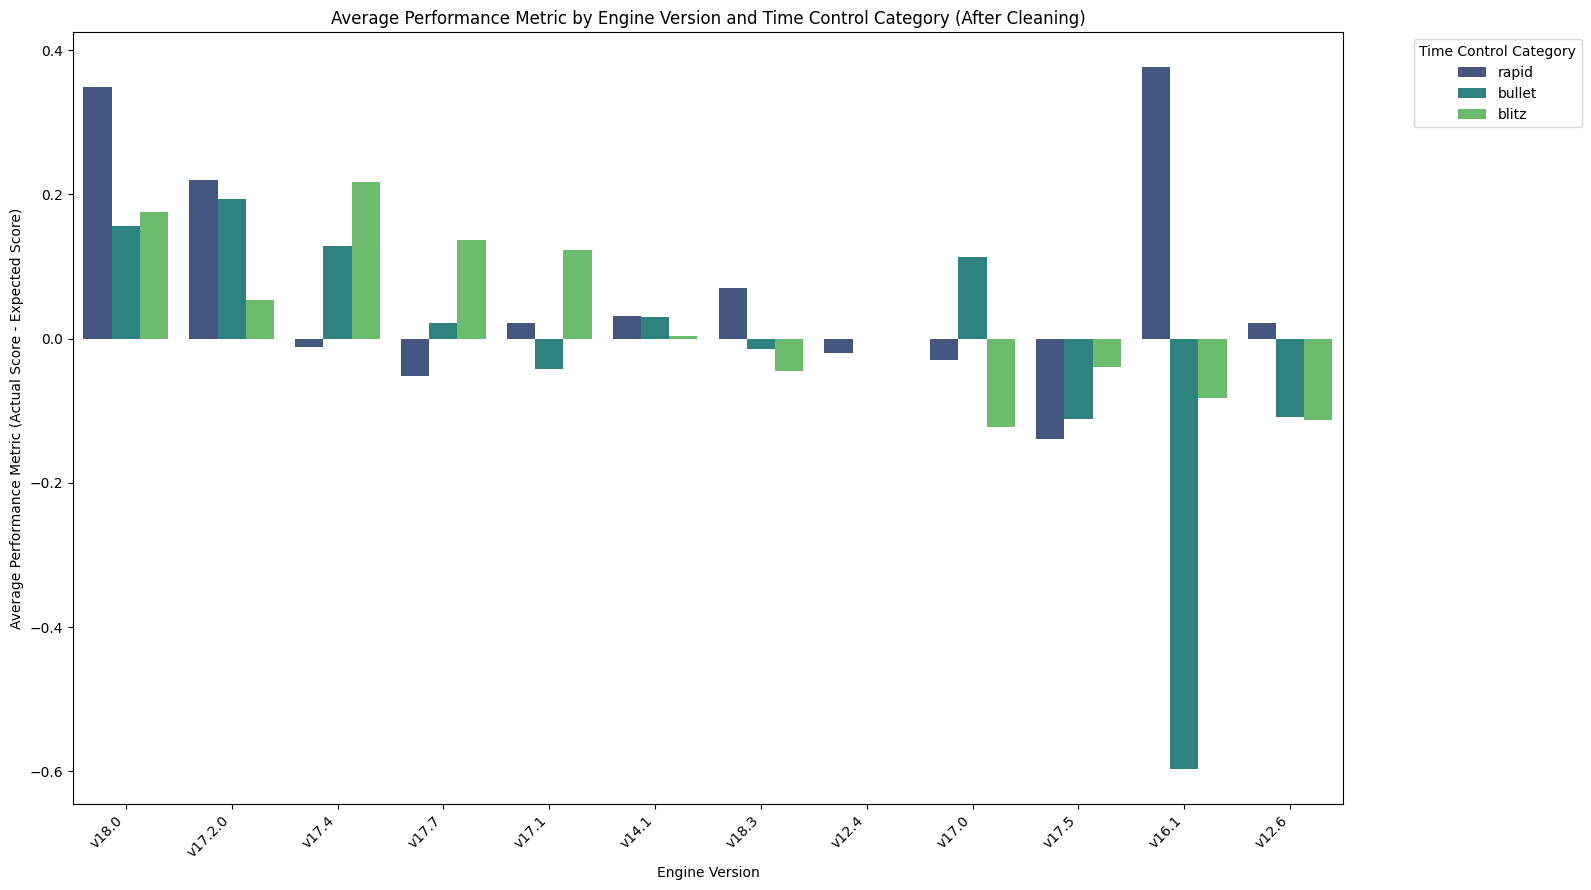

In [ ]:
plt.figure(figsize=(16, 9)) # Adjust figure size for better readability
sns.barplot(x='engine_version', y='performance_metric', hue='time_control_category',
            data=performance_by_time_control_category, palette='viridis',
            order=overall_engine_order_cleaned) # Use cleaned engine order
plt.title('Average Performance Metric by Engine Version and Time Control Category (After Cleaning)')
plt.xlabel('Engine Version')
plt.ylabel('Average Performance Metric (Actual Score - Expected Score)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Time Control Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Elo Distribution by Engine Version
To further investigate engine performance and specifically the Elo achievements of `v18.3`, let's visualize the distribution of `v7p3r_elo` for each engine version using box and whisker plots. This will help us understand the typical Elo range, the interquartile spread, and identify any outliers.

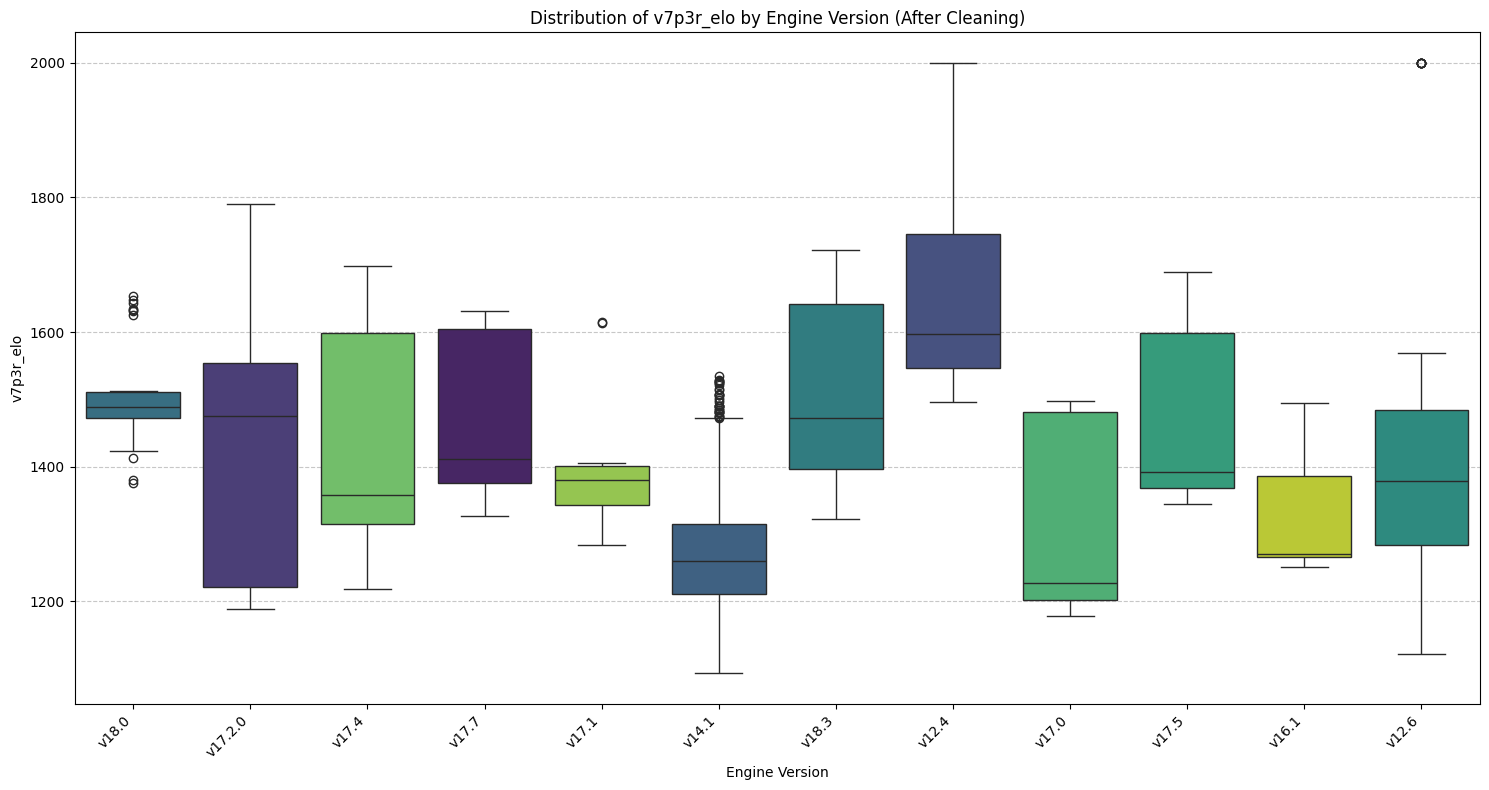

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='engine_version', y='v7p3r_elo', data=games_df_cleaned, palette='viridis', order=overall_engine_order_cleaned, hue='engine_version', legend=False)
plt.title('Distribution of v7p3r_elo by Engine Version (After Cleaning)')
plt.xlabel('Engine Version')
plt.ylabel('v7p3r_elo')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Detailed Comparison: `v18.3` vs. `v12.4`

Let's isolate the performance metrics for `v18.3` and `v12.4` to understand their behavior across different time control categories and investigate the Elo metrics further.

In [ ]:
# Filter performance by time control category for v18.3 and v12.4
comparison_performance = performance_by_time_control_category[
    (performance_by_time_control_category['engine_version'] == 'v18.3') |
    (performance_by_time_control_category['engine_version'] == 'v12.4')
].sort_values(by='engine_version')

print("Average Performance Metric for v18.3 and v12.4 by Time Control Category:")
display(comparison_performance)

Average Performance Metric for v18.3 and v12.4 by Time Control Category:


,engine_version,time_control_category,performance_metric
31,v18.3,blitz,-0.044511
33,v18.3,rapid,0.069657
32,v18.3,bullet,-0.014341
0,v12.4,rapid,-0.019592


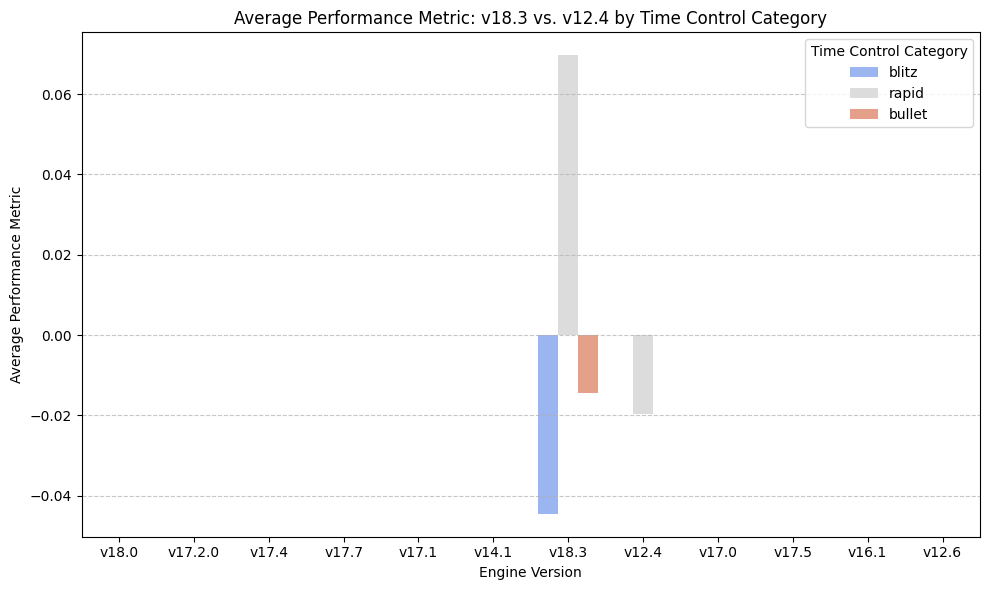

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='engine_version', y='performance_metric', hue='time_control_category',
            data=comparison_performance, palette='coolwarm')
plt.title('Average Performance Metric: v18.3 vs. v12.4 by Time Control Category')
plt.xlabel('Engine Version')
plt.ylabel('Average Performance Metric')
plt.xticks(rotation=0)
plt.legend(title='Time Control Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Now, let's look at the distribution of `v7p3r_elo` for these two specific engine versions to understand their Elo achievements.

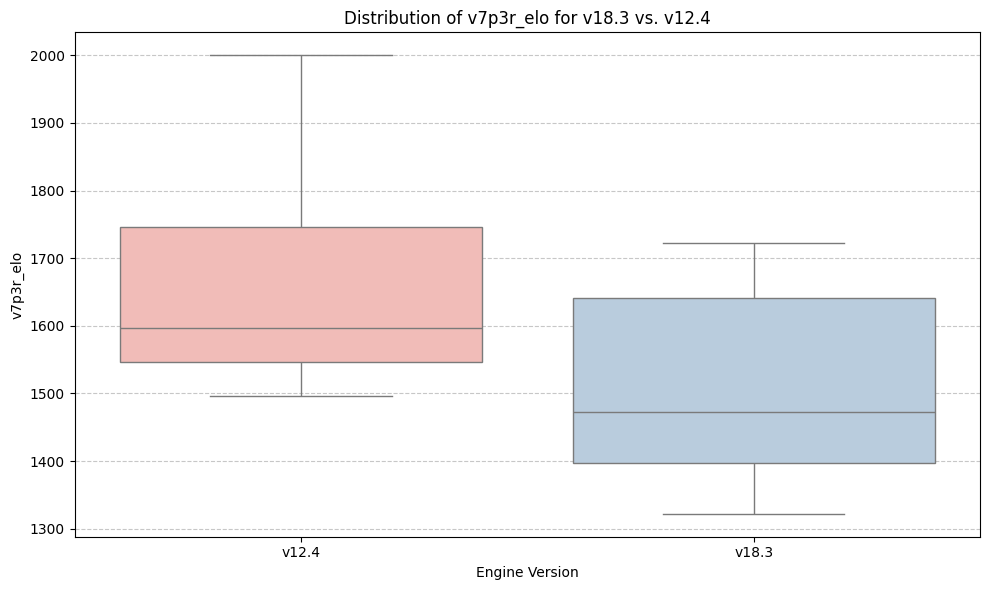

In [ ]:
# Filter cleaned data for v18.3 and v12.4
filtered_elo_comparison_df = games_df_cleaned[
    (games_df_cleaned['engine_version'] == 'v18.3') |
    (games_df_cleaned['engine_version'] == 'v12.4')
]

plt.figure(figsize=(10, 6))
sns.boxplot(x='engine_version', y='v7p3r_elo', data=filtered_elo_comparison_df,
            palette='Pastel1', hue='engine_version', legend=False)
plt.title('Distribution of v7p3r_elo for v18.3 vs. v12.4')
plt.xlabel('Engine Version')
plt.ylabel('v7p3r_elo')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Loading and Inspecting Move Data

To analyze `v18.3`'s move decisions, we need to load the `conformed_layer.moves` dataset. Since this is a large table (a million rows), we will load a limited sample to understand its structure and then devise a strategy for comprehensive analysis.

### Re-loading `v18.3`'s Moves for Comprehensive Analysis
The previous analysis was based on a small sample of `v18.3`'s moves. To get a complete picture of its strategies, especially concerning knight tactics, king safety, and endgame patterns, we need to load all available moves for games where `v18.3` was the engine. We'll achieve this by first identifying all `game_id`s associated with `v18.3` from our `games_df_cleaned` and then querying the `conformed_layer.moves` table specifically for those games.

In [ ]:
# Extract all game_ids where the engine version is 'v18.3'
v18_3_game_ids = games_df_cleaned[games_df_cleaned['engine_version'] == 'v18.3']['game_id'].unique().tolist()

print(f"Found {len(v18_3_game_ids)} games played by v18.3.")

if not v18_3_game_ids:
    print("No v18.3 games found in the cleaned game data. Please check the 'games_df_cleaned' DataFrame.")
else:
    # Construct a BigQuery query to fetch all moves for these game_ids
    # Using an IN clause for a list of game_ids
    game_ids_str = ', '.join([f"'{gid}'" for gid in v18_3_game_ids])
    query_v18_3_moves = f"""SELECT * FROM `{PROJECT_ID}.{MOVES_TABLE_ID}` WHERE game_id IN ({game_ids_str})"""

    # Load the comprehensive moves data for v18.3
    moves_df_v18_3_full = pandas_gbq.read_gbq(query_v18_3_moves, project_id=PROJECT_ID)

    print("First 5 rows of the comprehensive v18.3 moves data:")
    display(moves_df_v18_3_full.head())
    print("\nInfo about the comprehensive v18.3 moves data:")
    moves_df_v18_3_full.info()

Found 315 games played by v18.3.
Downloading: 100%|██████████|
First 5 rows of the comprehensive v18.3 moves data:


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,game_id,move_number,color,san,piece,is_capture,is_check,is_castle,castle_side,clock,white_material,black_material,material_balance,game_phase,ingested_at
0,qyViMIwm,52,black,52...,P,False,False,False,None,None,39,6,33,middlegame,2026-04-30 18:02:32.363549+00:00
1,Tph80sjt,56,black,56...,P,False,False,False,None,None,39,12,27,middlegame,2026-04-30 18:02:32.363549+00:00
2,Xa7Q3F70,59,black,59...,P,False,False,False,None,None,39,-3,42,endgame,2026-04-30 18:02:39.767053+00:00
3,bS5tm9qP,53,white,Bxe5,B,True,False,False,None,0:04:32,39,0,39,endgame,2026-04-30 18:02:39.767053+00:00
4,Xa7Q3F70,56,white,Ke4,K,False,False,False,None,0:04:28,39,0,39,endgame,2026-04-30 18:02:39.767053+00:00



Info about the comprehensive v18.3 moves data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72165 entries, 0 to 72164
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   game_id           72165 non-null  object             
 1   move_number       72165 non-null  Int64              
 2   color             72165 non-null  object             
 3   san               72165 non-null  object             
 4   piece             72165 non-null  object             
 5   is_capture        72165 non-null  boolean            
 6   is_check          72165 non-null  boolean            
 7   is_castle         72165 non-null  boolean            
 8   castle_side       569 non-null    object             
 9   clock             34150 non-null  object             
 10  white_material    72165 non-null  Int64              
 11  black_material    72165 non-null  Int64              
 12  material_bal

### Merging Comprehensive `v18.3` Moves Data with Game Info
Now, we'll merge this comprehensive `moves_df_v18_3_full` with the relevant game information from `games_df_cleaned` to ensure each move is linked to its game context and `v7p3r`'s color.

In [ ]:
# Merge the comprehensive moves_df_v18_3_full with game info, including v7p3r's game color
moves_with_game_info_v18_3_full_df = pd.merge(
    moves_df_v18_3_full,
    games_df_cleaned[['game_id', 'engine_version', 'v7p3r_elo', 'opponent_elo', 'relative_opponent_strength', 'game_type', 'color']].rename(columns={'color': 'v7p3r_game_color'}),
    on='game_id',
    how='left'
)

print("First 5 rows of merged comprehensive v18.3 moves and game info data:")
display(moves_with_game_info_v18_3_full_df.head())
print("\nInfo about the merged comprehensive data:")
moves_with_game_info_v18_3_full_df.info()

First 5 rows of merged comprehensive v18.3 moves and game info data:


,game_id,move_number,color,san,piece,is_capture,is_check,is_castle,castle_side,clock,...,black_material,material_balance,game_phase,ingested_at,engine_version,v7p3r_elo,opponent_elo,relative_opponent_strength,game_type,v7p3r_game_color
0,qyViMIwm,52,black,52...,P,False,False,False,None,None,...,6,33,middlegame,2026-04-30 18:02:32.363549+00:00,v18.3,1484,1395,equal,lichess_rated,black
1,Tph80sjt,56,black,56...,P,False,False,False,None,None,...,12,27,middlegame,2026-04-30 18:02:32.363549+00:00,v18.3,1362,1563,stronger,lichess_rated,white
2,Xa7Q3F70,59,black,59...,P,False,False,False,None,None,...,-3,42,endgame,2026-04-30 18:02:39.767053+00:00,v18.3,1348,1393,equal,lichess_rated,black
3,bS5tm9qP,53,white,Bxe5,B,True,False,False,None,0:04:32,...,0,39,endgame,2026-04-30 18:02:39.767053+00:00,v18.3,1404,1319,equal,lichess_rated,white
4,Xa7Q3F70,56,white,Ke4,K,False,False,False,None,0:04:28,...,0,39,endgame,2026-04-30 18:02:39.767053+00:00,v18.3,1348,1393,equal,lichess_rated,black



Info about the merged comprehensive data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72165 entries, 0 to 72164
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   game_id                     72165 non-null  object             
 1   move_number                 72165 non-null  Int64              
 2   color                       72165 non-null  object             
 3   san                         72165 non-null  object             
 4   piece                       72165 non-null  object             
 5   is_capture                  72165 non-null  boolean            
 6   is_check                    72165 non-null  boolean            
 7   is_castle                   72165 non-null  boolean            
 8   castle_side                 569 non-null    object             
 9   clock                       34150 non-null  object             
 10  white_material 

### Isolating `v18.3`'s Own Moves (Comprehensive Dataset)
Finally, we'll filter this merged DataFrame to include only the moves made by `v18.3` itself, by matching the move's color with the color `v7p3r` played in that game.

In [ ]:
# Filter for moves made by 'v18.3' and where the 'color' of the move matches the 'v7p3r_game_color' for that game
v18_3_moves_df_full = moves_with_game_info_v18_3_full_df[
    (moves_with_game_info_v18_3_full_df['engine_version'] == 'v18.3') &
    (moves_with_game_info_v18_3_full_df['color'] == moves_with_game_info_v18_3_full_df['v7p3r_game_color'])
]

print("First 5 rows of comprehensive v18.3's own moves:")
display(v18_3_moves_df_full.head())
print("\nTotal number of v18.3's moves for full analysis:", len(v18_3_moves_df_full))

First 5 rows of comprehensive v18.3's own moves:


,game_id,move_number,color,san,piece,is_capture,is_check,is_castle,castle_side,clock,...,black_material,material_balance,game_phase,ingested_at,engine_version,v7p3r_elo,opponent_elo,relative_opponent_strength,game_type,v7p3r_game_color
0,qyViMIwm,52,black,52...,P,False,False,False,None,None,...,6,33,middlegame,2026-04-30 18:02:32.363549+00:00,v18.3,1484,1395,equal,lichess_rated,black
2,Xa7Q3F70,59,black,59...,P,False,False,False,None,None,...,-3,42,endgame,2026-04-30 18:02:39.767053+00:00,v18.3,1348,1393,equal,lichess_rated,black
3,bS5tm9qP,53,white,Bxe5,B,True,False,False,None,0:04:32,...,0,39,endgame,2026-04-30 18:02:39.767053+00:00,v18.3,1404,1319,equal,lichess_rated,white
6,XyDiuZjM,52,black,52...,P,False,False,False,None,None,...,6,33,middlegame,2026-04-30 18:02:39.767053+00:00,v18.3,1371,1412,equal,lichess_rated,black
8,Tph80sjt,51,white,Be1,B,False,False,False,None,0:02:52,...,12,27,middlegame,2026-04-30 18:02:39.767053+00:00,v18.3,1362,1563,stronger,lichess_rated,white



Total number of v18.3's moves for full analysis: 35834


In [ ]:
# Define the BigQuery table for moves data
MOVES_TABLE_ID = 'conformed_layer.moves'

# Load a sample of the moves data (e.g., 10,000 rows) for initial inspection
query_moves_sample = f"""SELECT * FROM `{PROJECT_ID}.{MOVES_TABLE_ID}` LIMIT 10000"""
moves_df = pandas_gbq.read_gbq(query_moves_sample, project_id=PROJECT_ID)

print("First 5 rows of the moves data:")
display(moves_df.head())
print("\nInfo about the moves data:")
moves_df.info()

Downloading: 100%|██████████|
First 5 rows of the moves data:


,game_id,move_number,color,san,piece,is_capture,is_check,is_castle,castle_side,clock,white_material,black_material,material_balance,game_phase,ingested_at
0,2eIDIK2B,111,black,111...,P,False,False,False,None,None,39,-3,42,endgame,2026-04-30 18:02:44.733663+00:00
1,2eIDIK2B,111,black,111...,P,False,False,False,None,None,39,-3,42,endgame,2026-04-30 18:02:24.070269+00:00
2,2eIDIK2B,111,black,111...,P,False,False,False,None,None,39,-3,42,endgame,2026-04-30 18:03:21.754668+00:00
3,2eIDIK2B,112,black,112...,P,False,False,False,None,None,39,-3,42,endgame,2026-04-30 18:02:44.733663+00:00
4,2eIDIK2B,112,black,112...,P,False,False,False,None,None,39,-3,42,endgame,2026-04-30 18:02:24.070269+00:00



Info about the moves data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   game_id           10000 non-null  object             
 1   move_number       10000 non-null  Int64              
 2   color             10000 non-null  object             
 3   san               10000 non-null  object             
 4   piece             10000 non-null  object             
 5   is_capture        10000 non-null  boolean            
 6   is_check          10000 non-null  boolean            
 7   is_castle         10000 non-null  boolean            
 8   castle_side       48 non-null     object             
 9   clock             5053 non-null   object             
 10  white_material    10000 non-null  Int64              
 11  black_material    10000 non-null  Int64              
 12  material_balance  10000 non-null 

### Merging Moves Data with Game Data
To analyze `v18.3`'s moves in the context of the game, we need to merge the `moves_df` with the `games_df_cleaned` on `game_id`. This will allow us to link each move to its corresponding game and engine version.

In [ ]:
# Merge moves_df with games_df_cleaned to link moves to game and engine information
moves_with_game_info_df = pd.merge(moves_df, games_df_cleaned[['game_id', 'engine_version', 'v7p3r_elo', 'opponent_elo', 'relative_opponent_strength', 'game_type', 'color']].rename(columns={'color': 'v7p3r_game_color'}), on='game_id', how='left')

print("First 5 rows of merged moves and game info data:")
display(moves_with_game_info_df.head())
print("\nInfo about the merged data:")
moves_with_game_info_df.info()

First 5 rows of merged moves and game info data:


,game_id,move_number,color,san,piece,is_capture,is_check,is_castle,castle_side,clock,...,black_material,material_balance,game_phase,ingested_at,engine_version,v7p3r_elo,opponent_elo,relative_opponent_strength,game_type,v7p3r_game_color
0,2eIDIK2B,111,black,111...,P,False,False,False,None,None,...,-3,42,endgame,2026-04-30 18:02:44.733663+00:00,NaN,<NA>,<NA>,NaN,NaN,NaN
1,2eIDIK2B,111,black,111...,P,False,False,False,None,None,...,-3,42,endgame,2026-04-30 18:02:24.070269+00:00,NaN,<NA>,<NA>,NaN,NaN,NaN
2,2eIDIK2B,111,black,111...,P,False,False,False,None,None,...,-3,42,endgame,2026-04-30 18:03:21.754668+00:00,NaN,<NA>,<NA>,NaN,NaN,NaN
3,2eIDIK2B,112,black,112...,P,False,False,False,None,None,...,-3,42,endgame,2026-04-30 18:02:44.733663+00:00,NaN,<NA>,<NA>,NaN,NaN,NaN
4,2eIDIK2B,112,black,112...,P,False,False,False,None,None,...,-3,42,endgame,2026-04-30 18:02:24.070269+00:00,NaN,<NA>,<NA>,NaN,NaN,NaN



Info about the merged data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   game_id                     10000 non-null  object             
 1   move_number                 10000 non-null  Int64              
 2   color                       10000 non-null  object             
 3   san                         10000 non-null  object             
 4   piece                       10000 non-null  object             
 5   is_capture                  10000 non-null  boolean            
 6   is_check                    10000 non-null  boolean            
 7   is_castle                   10000 non-null  boolean            
 8   castle_side                 48 non-null     object             
 9   clock                       5053 non-null   object             
 10  white_material              10

### Isolating `v18.3`'s Moves
Now, let's filter the merged DataFrame to only include moves made by `v18.3`. We also need to ensure we're looking at moves made by `v18.3` itself, not its opponent.

In [ ]:
# Filter for moves made by 'v18.3' and where the 'color' of the move matches the 'v7p3r_game_color' for that game
v18_3_moves_df = moves_with_game_info_df[
    (moves_with_game_info_df['engine_version'] == 'v18.3') &
    (moves_with_game_info_df['color'] == moves_with_game_info_df['v7p3r_game_color'])
]

print("First 5 rows of v18.3's moves:")
display(v18_3_moves_df.head())
print("\nNumber of v18.3 moves:", len(v18_3_moves_df))

First 5 rows of v18.3's moves:


,game_id,move_number,color,san,piece,is_capture,is_check,is_castle,castle_side,clock,...,black_material,material_balance,game_phase,ingested_at,engine_version,v7p3r_elo,opponent_elo,relative_opponent_strength,game_type,v7p3r_game_color
2796,9ai9RDV8,86,white,Kc4,K,False,False,False,None,0:00:17,...,15,24,middlegame,2026-04-30 18:02:39.767053+00:00,v18.3,1371,1652,stronger,lichess_rated,white
2797,9ai9RDV8,86,white,Kc4,K,False,False,False,None,0:00:17,...,15,24,middlegame,2026-04-30 18:02:36.428034+00:00,v18.3,1371,1652,stronger,lichess_rated,white
2798,9ai9RDV8,86,white,Kc4,K,False,False,False,None,0:00:17,...,15,24,middlegame,2026-04-30 18:03:16.959228+00:00,v18.3,1371,1652,stronger,lichess_rated,white
2799,9ai9RDV8,81,white,Kd2,K,False,False,False,None,0:00:37,...,15,24,middlegame,2026-04-30 18:03:16.959228+00:00,v18.3,1371,1652,stronger,lichess_rated,white
2800,9ai9RDV8,81,white,Kd2,K,False,False,False,None,0:00:37,...,15,24,middlegame,2026-04-30 18:02:36.428034+00:00,v18.3,1371,1652,stronger,lichess_rated,white



Number of v18.3 moves: 126


### Analyzing `v18.3`'s Moves by Material Balance
To understand `v18.3`'s move decisions, we'll categorize the `material_balance` from its perspective (advantage, disadvantage, or even). This will help us analyze trends based on the material position.

In [ ]:
def get_material_position(row):
    if row['v7p3r_game_color'] == 'white':
        if row['material_balance'] > 0:
            return 'Advantage'
        elif row['material_balance'] < 0:
            return 'Disadvantage'
        else:
            return 'Even'
    else: # v7p3r_game_color == 'black'
        if row['material_balance'] < 0:
            return 'Advantage'
        elif row['material_balance'] > 0:
            return 'Disadvantage'
        else:
            return 'Even'

v18_3_moves_df_full_copy = v18_3_moves_df_full.copy() # Create an explicit copy to avoid SettingWithCopyWarning
v18_3_moves_df_full_copy['v18_3_material_position'] = v18_3_moves_df_full_copy.apply(get_material_position, axis=1)

print("Distribution of v18.3's material positions (Comprehensive Data):")
display(v18_3_moves_df_full_copy['v18_3_material_position'].value_counts().reset_index())

Distribution of v18.3's material positions (Comprehensive Data):


,v18_3_material_position,count
0,Disadvantage,15507
1,Advantage,15228
2,Even,5099


### Analyzing `v18.3`'s Piece Frequencies by Game Phase
To understand `v18.3`'s decision-making patterns, let's look at the frequency of pieces it moves, broken down by game phase (opening, middlegame, endgame). This will reveal if `v18.3` changes its piece focus as the game progresses.

In [ ]:
# Calculate piece frequencies by game phase for v18.3 using the full dataset
piece_frequency_by_phase = v18_3_moves_df_full_copy.groupby(['game_phase', 'piece']).size().reset_index(name='count')

# Sort the game phases for better visualization order
phase_order = ['opening', 'middlegame', 'endgame']
piece_frequency_by_phase['game_phase'] = pd.Categorical(piece_frequency_by_phase['game_phase'], categories=phase_order, ordered=True)
piece_frequency_by_phase = piece_frequency_by_phase.sort_values(['game_phase', 'count'], ascending=[True, False])

print("Piece Frequencies by Game Phase for v18.3 (Comprehensive Data):")
display(piece_frequency_by_phase)

Piece Frequencies by Game Phase for v18.3 (Comprehensive Data):


,game_phase,piece,count
15,opening,P,9026
14,opening,N,1624
16,opening,Q,1522
12,opening,B,919
17,opening,R,387
13,opening,K,368
9,middlegame,P,12356
11,middlegame,R,2553
7,middlegame,K,2253
6,middlegame,B,1746


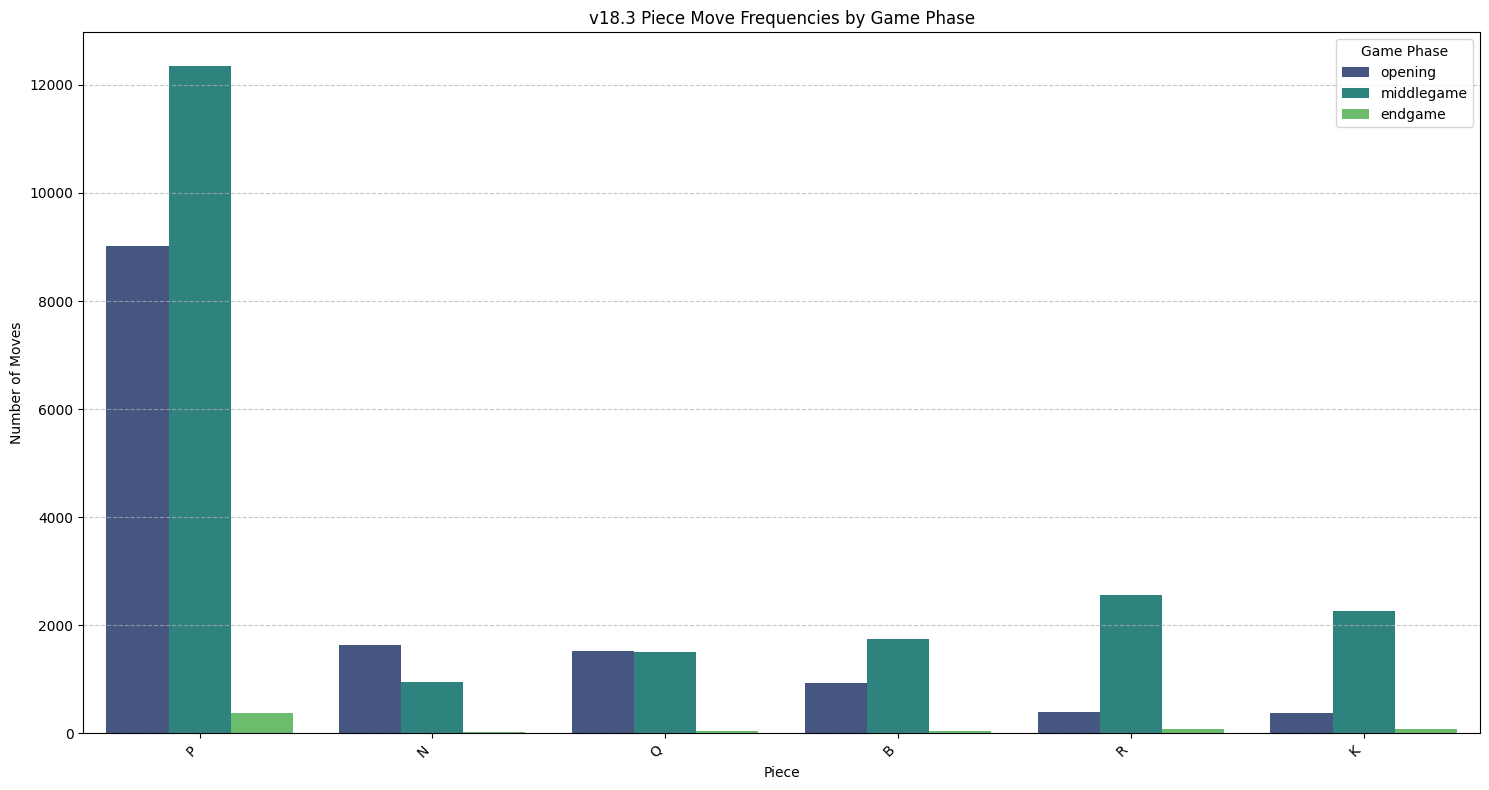

In [ ]:
plt.figure(figsize=(15, 8))
sns.barplot(x='piece', y='count', hue='game_phase', data=piece_frequency_by_phase, palette='viridis')
plt.title('v18.3 Piece Move Frequencies by Game Phase')
plt.xlabel('Piece')
plt.ylabel('Number of Moves')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Game Phase')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

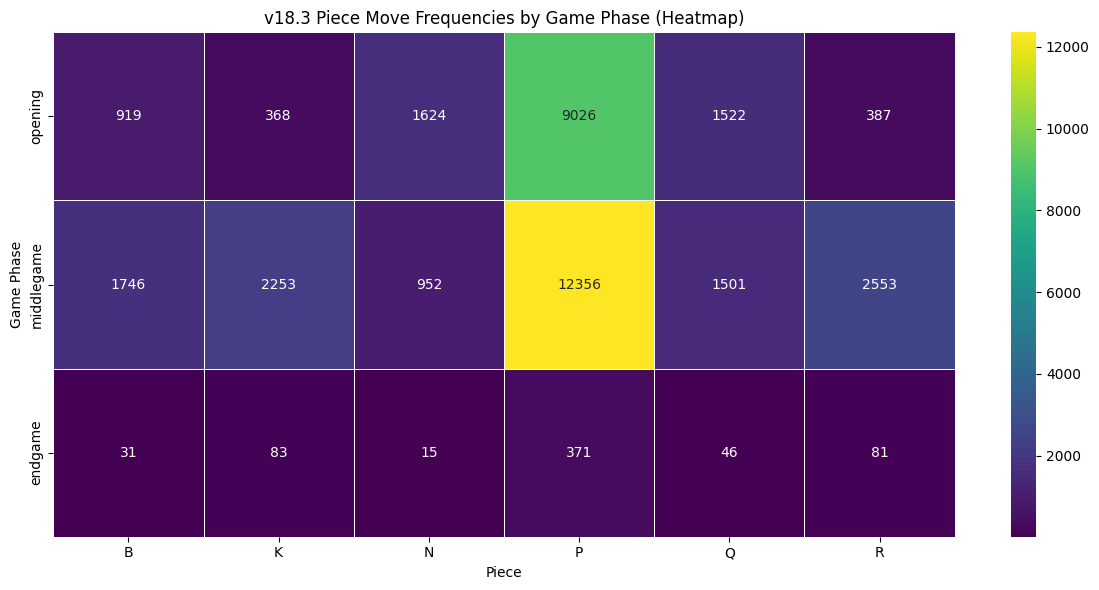

In [ ]:
# Pivot the table for heatmap visualization
heatmap_data = piece_frequency_by_phase.pivot(index='game_phase', columns='piece', values='count').fillna(0)

# Reorder columns for better visualization (optional, based on common piece order)
piece_order = ['P', 'N', 'B', 'R', 'Q', 'K']
heatmap_data = heatmap_data[heatmap_data.columns.intersection(piece_order)]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='viridis', linewidths=.5)
plt.title('v18.3 Piece Move Frequencies by Game Phase (Heatmap)')
plt.xlabel('Piece')
plt.ylabel('Game Phase')
plt.tight_layout()
plt.show()